# CA2 - Supervised machine learning classification pipeline - applied to pumpkin seed variety classification


### Important information

- Do __not__ use scikit-learn (`sklearn`) or any other high-level machine learning library for this CA
- Explain your code and reasoning in markdown cells or code comments
- Label all graphs and charts if applicable
- If you use code from the internet, make sure to reference it and explain it in your own words
- If you use additional function arguments, make sure to explain them in your own words
- Use the classes `Perceptron`, `Adaline` and `Logistic Regression` from the library `mlxtend` as classifiers (`from mlxtend.classifier import Perceptron, Adaline, LogisticRegression`). _Always_ use the argument `minibatches=1` when instantiating an `Adaline` or `LogisticRegression` object. This makes the model use the gradient descent algorithm for training. Always use the `random_seed=42` argument when instantiating the classifiers. This will make your results reproducible.
- You can use any plotting library you want (e.g. `matplotlib`, `seaborn`, `plotly`, etc.)
- Use explanatory variable names (e.g. `X_train` and `X_train_scaled` for the training data before and after scaling, respectively)
- The dataset is provided in the file `pumpkin_dataset.csv` 

### About the dataset

Each row describes one pumpkin seed, measured automatically from a photograph. The four features are geometric properties of the seed:

- `Compactness`: how close the seed's shape is to a circle (ratio; 1 = perfectly round, smaller = more elongated)
- `Major_Axis_Length`: length of the longest line that fits inside the seed (pixels)
- `Extent`: ratio of the seed area to the area of its bounding box
- `Area`: number of pixels inside the seed

The target `class` is the seed variety: `0` = Çerçevelik, `1` = Ürgüp Sivrisi.

The data comes from Koklu, Sarigil & Ozbek (2021), *The use of machine learning methods in classification of pumpkin seeds (Cucurbita pepo L.)*, Genetic Resources and Crop Evolution 68(7), 2713–2726. https://doi.org/10.1007/s10722-021-01226-0

### Additional clues

- Use the `pandas` library for initial data inspection and preprocessing
- Before training the classifiers, convert the data to raw `numpy` arrays
- For Part IV, you are aiming to create a plot that looks similar to this:
<img src="./example_output_pumpkin.png" width="700">

### Additional information

- Feel free to create additional code or markdown cells if you think it will help you explain your reasoning or structure your code (you don't have to).


## Part I: Data loading and data exploration


### Import necessary libraries/modules:


In [18]:
# Insert your code below
# ======================
from mlxtend.classifier import Perceptron, Adaline, LogisticRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading and exploring data

1. Load the dataset `pumpkin_dataset.csv` with `pandas`.
2. Check for missing data, report your findings, and remove samples with missing data if any are present.
3. Display the raw data with appropriate plots/outputs and inspect it. Describe the distributions of:
   - feature `"Compactness"`
   - feature `"Area"`
   - the target variable `"class"`
4. Will it be beneficial to scale the data? Why or why not?
5. Is the data linearly separable using any pairwise combination of features? Based on your observations, can we expect an accuracy close to 100% from a linear classifier?


(2500, 5)
(2500, 5)
Index(['Compactness', 'Major_Axis_Length', 'Extent', 'Area', 'class'], dtype='object')
*************************************************************
Since no rows have been removed there issn`t any data missing
*************************************************************


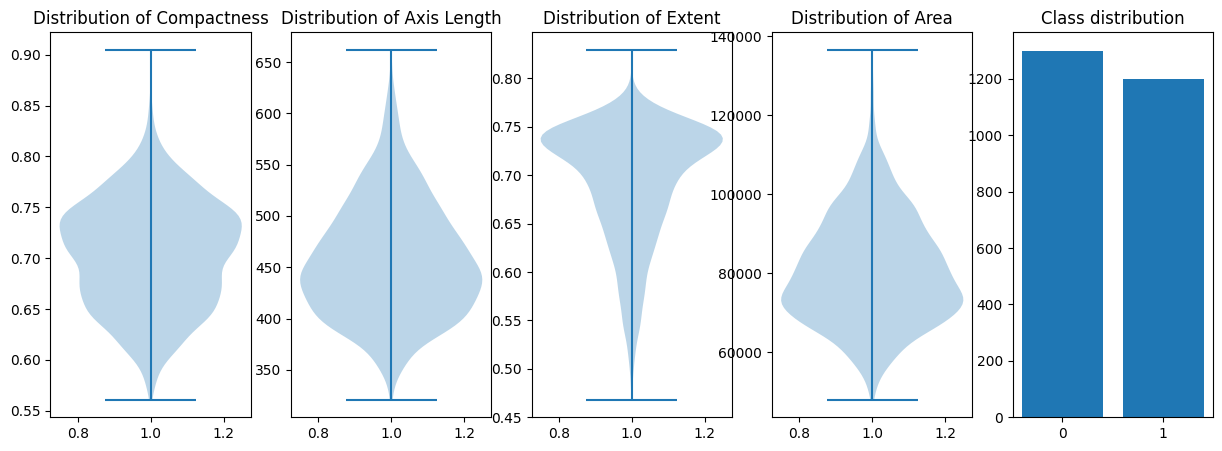

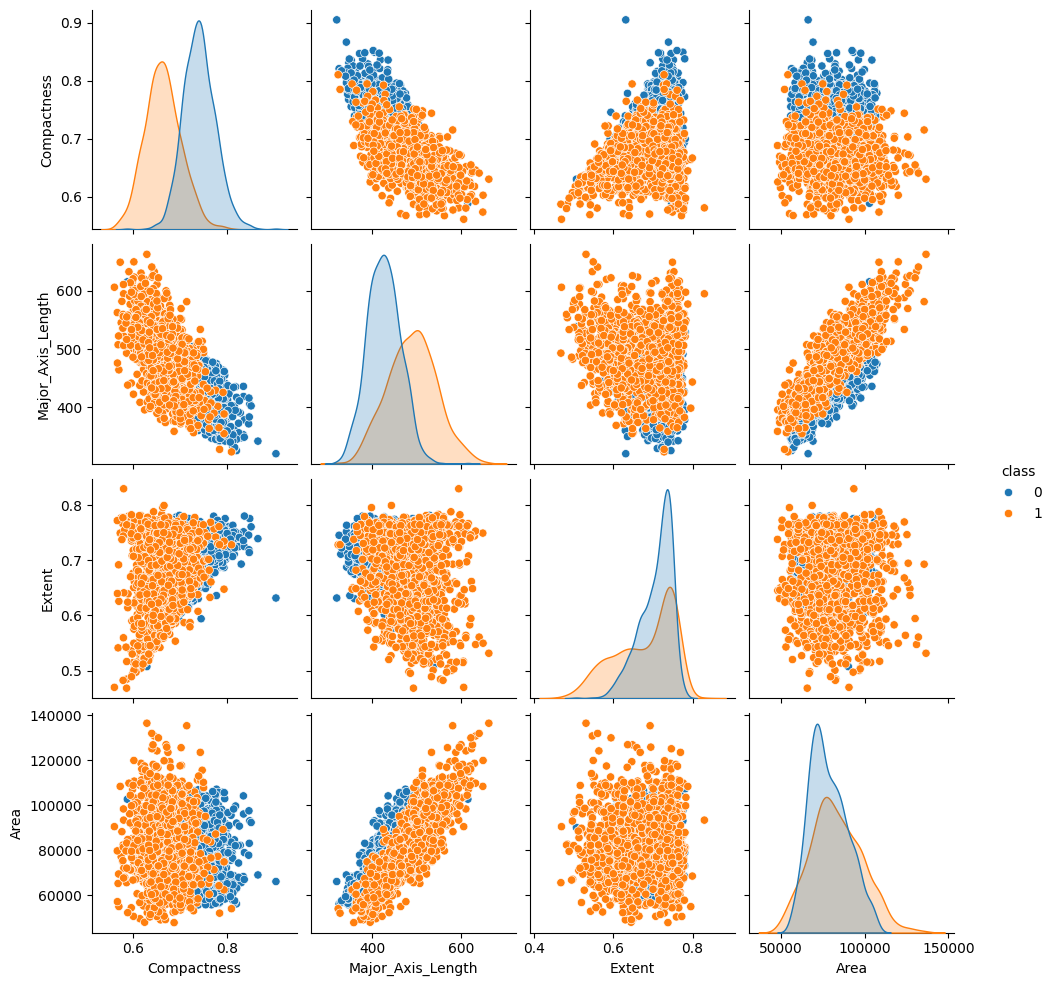

In [19]:
# Insert your code below
# ======================
data = pd.read_csv("pumpkin_dataset.csv")

print(data.shape)
data = data.dropna()
print(data.shape)

print(data.columns)

print("*"*61)
print("Since no rows have been removed there issn`t any data missing")
print("*"*61)


fig, ax = plt.subplots(1, 5, figsize=(15,5))

ax[0].violinplot(data["Compactness"])
ax[0].set_title("Distribution of Compactness")

ax[1].violinplot(data["Major_Axis_Length"])
ax[1].set_title("Distribution of Axis Length")

ax[2].violinplot(data["Extent"])
ax[2].set_title("Distribution of Extent")

ax[3].violinplot(data["Area"])
ax[3].set_title("Distribution of Area")

ax[4].bar(
    data["class"].value_counts().sort_index().index,
    data["class"].value_counts().sort_index().values
)

ax[4].set_title("Class distribution")
ax[4].set_xticks([0, 1])

plt.show()



sns.pairplot(
    data,
    vars=["Compactness", "Major_Axis_Length", "Extent", "Area"],
    hue="class"
)

plt.show()



## Compactness

The distribution of compactness is fairly good, and the distrobution have a peak at around 0.74

## Area

The distribution of area is right-skewed with most entries on the lower side of its scale and a long tail upward, the distribution peaks at around 75 000

## class

There are two classes, with class 0 having slightly more entries than class 1

## Scaling
It will be highly beneficial to scale the data, since the compactness uses values between 0 and 1 while the area uses value going up towards 140 000

## Linearly seperable

Based on the pairplots the data does not seem to be linearly seperable, so we do not expect to get 100% accuracy

## Part II: Train/Test Split

Divide your dataset into training and testing subsets. Follow these steps to create the split:

1. **Divide the dataset into two data sets, each containing samples of only one class:**
   - Create a DataFrame `df_0` containing all samples with `"class"` equal to `0`.
   - Create a DataFrame `df_1` containing all samples with `"class"` equal to `1`.

2. **Split into training and test sets by randomly sampling entries from the data frames:**
   - Create a DataFrame `df_0_train` by sampling `75%` of the entries from `df_0` (use the `sample` method with `random_state=42`).
   - Create a DataFrame `df_1_train` using the same approach with `df_1`.
   - Create a DataFrame `df_0_test` containing the remaining entries of `df_0` (use `df_0.drop(df_0_train.index)`).
   - Create a DataFrame `df_1_test` using the same approach with `df_1`.

3. **Merge the datasets split by classes back together:**
   - Create a DataFrame `df_train` containing all entries from `df_0_train` and `df_1_train` (use the `concat` method).
   - Create a DataFrame `df_test` containing all entries from the two test sets.

4. **Create the following data frames from these splits:**
   - `X_train`: contains all columns of `df_train` except for the target feature `"class"`
   - `X_test`: contains all columns of `df_test` except for the target feature `"class"`
   - `y_train`: contains only the target feature `"class"` for all samples in the training set
   - `y_test`: contains only the target feature `"class"` for all samples in the test set

5. **Check that your sets have the expected sizes/shape by printing the number of rows and columns (`shape`) of the data sets.**
   - (Sanity check: there should be **4 features**, and the training set should contain roughly **75%** of the total samples, with the test set containing the remaining **25%**.)

6. **Explain the purpose of this slightly complicated procedure.**
   - Why did we first split into the two classes?
   - Why did we then split into a training and a testing set?

7. **What is the share (in percent) of samples with class `0` in the test set, training set, and in the initial data set?**


In [28]:
# Insert your code below
# ======================
"""
========================
    task description
========================
create df0 and df1
create df 0 and 1 train
create df 0 and 1 test

create df_train (concat 0 and 1)
create df test with all entries from test

X_train, X_test, y_train, y_test

Check for expected sizes and shapes, should contain 75% of total samples with the remaining 25% as test

Explain why split it into two classes, why a training set and a testing set
"""

# part 1, 
# creates a dataframe from the csv

# then uses that dataframe to create two new ones, each only containing pumpkins where class value is 0 or 1
df_0 = data[data["class"] == 0]
df_1 = data[data["class"] == 1]


# part 2, 
# create df_0_train from 75% of entries, df_1_train from 75% of entries, use sample and random_state=42 (the answer to the ultimate question itself)
# and df_0_test and df_1_test fropm the remaining 25% in  respective origin dataframe by dropping the data already used in the training sets

df_0_train = df_0.sample(frac=0.75, random_state=42) # use 75% of df_0, with random state = (see next line)
# = 42, (the answer to the ultimate question of life, the universe and everything)

df_1_train = df_1.sample(frac=0.75, random_state=42) # same as before, random state still the answer to the ultimate question of life, the universe and everything

# drop the indexes contained in the training data
df_0_test = df_0.drop(df_0_train.index)
df_1_test = df_1.drop(df_1_train.index)

# part 3,
# merge them back together using concat
df_train = pd.concat([df_0_train, df_1_train], ignore_index=True, sort=False)
df_test = pd.concat([df_0_test, df_1_test], ignore_index=True, sort=False)

# part 4,
# create the X_train, X_test, y_train, y_test
# X_train contains all  all columns of df_train except class
# X_test contains all columns of df_test except class
# y_train contains only target feature class
# y_test contains only target feature class

# create X train and test , and exclude the column "class"
X_train = df_train.drop(columns=["class"]).copy()
X_test = df_test.drop(columns=["class"]).copy()

# the oposite, y_train and test should ONLY have "class"
y_train = df_train[["class"]]
y_test = df_test[["class"]]

# part 5,
# sanity check
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

# part 6
# explain why divide it like this:
# there are 2 types of pumpkins and we separate them to keep the same ratio when training the model, since there are different amounts of each type of pumpkin

# part 7
# what is the share with class = 0, and what about class = 1?
df_tot = len(df_0) + len(df_1)
part_1 = (len(df_1) / df_tot) * 100
part_0 = (len(df_0) / df_tot) * 100
print(f"percentage for 0: {part_0}")
print(f"percentage for 1: {part_1}")

X_train: (1875, 4)
X_test: (625, 4)
y_train: (1875, 1)
y_test: (625, 1)
percentage for 0: 52.0
percentage for 1: 48.0


### Convert data to numpy arrays and shuffle the training data

Many machine learning models (including those you will use later in this assignment) do not accept `pandas` DataFrames as input. Instead, they require the data to be provided as raw `numpy` arrays.  
In this step, convert the DataFrames `X_train`, `X_test`, `y_train`, and `y_test` into the corresponding numpy arrays with the same variable names.

In addition, shuffle the training data. This is necessary because the training set is currently ordered by class (all samples of class 0 followed by all samples of class 1).  
In Part IV, the classifiers will be trained using the **first _n_ samples** of the training set. If the data were not shuffled, the models would initially be trained only on samples from a single class, which would lead to biased learning and unreliable performance.

Nothing to be done here, just execute the cell.


In [21]:
# convert to numpy arrays
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

# shuffle training data
np.random.seed(42) # for reproducibility
shuffle_index = np.random.permutation(len(X_train)) # generate random indices
X_train, y_train = X_train[shuffle_index], y_train[shuffle_index] # shuffle data by applying reordering with the random indices

## Part III: Scaling the data

1. Standardize the training _and_ test data so that each feature has a mean of 0 and a standard deviation of 1.
2. Check that the scaling was successful
   - by printing the mean and standard deviation of each feature in the scaled training set
   - by putting the scaled training set into a DataFrame and making a violin plot of the data

__Hint:__ use the `axis` argument to calculate mean and standard deviation column-wise.

__Important:__ Avoid data leakage!  
Compute the mean and standard deviation only on the training data, and then apply the same transformation to both the training and test sets.

__More hints:__

1. For each column, subtract the training mean $(\mu_{\text{train}})$ from each value in that column  
2. Divide the result by the training standard deviation $(\sigma_{\text{train}})$

Mathematically, this transformation for each column is:

$$ X_{\text{scaled}} = \frac{X - \mu_{\text{train}}}{\sigma_{\text{train}}}$$

where:
- $X_{\text{scaled}}$ are the transformed column values (a column vector)  
- $X$ is the original column  
- $\mu_{\text{train}}$ is the mean of the column computed on the training set  
- $\sigma_{\text{train}}$ is the standard deviation of the column computed on the training set  


In [22]:
# Insert your code below
# ======================


## Part IV: Training and evaluation with different dataset sizes and training times

Often, a larger dataset size will yield better model performance. (As we will learn later, this usually prevents overfitting and increases the generalization capability of the trained model.)
However, collecting data is usually rather expensive.

In this part of the exercise, you will investigate

- how the model performance changes with varying dataset size
- how the model performance changes with varying numbers of epochs/iterations of the optimizer/solver (increasing training time).

For this task (Part IV), use the `Adaline`, `Perceptron`, and `LogisticRegression` classifiers from the `mlxtend` library. All use the gradient descent (GD) algorithm for training.

__Important__: Use a learning rate of `1e-5` (`0.00001`) for all classifiers, and use the argument `minibatches=1` when initializing the `Adaline` and `LogisticRegression` classifiers (this will make sure they use GD). For all three classifiers, pass `random_seed=42` when initializing the classifier to ensure reproducibility of the results.

### Model training

Train the models using progressively larger subsets of your dataset, specifically: first 50 rows, first 100 rows, first 150 rows, ..., first 650 rows, first 700 rows (in total $14$ different variants).

For each number of rows train the model with progressively larger number of epochs: 2, 7, 12, 17, ..., 87, 92, 97 (in total $20$ different model variants).

This will result in $14 \times 20 = 280$ models obtained from the different combinations of subsets and number of epochs. An output of the training process could look like this:

```
Model (1) Train a model with first 50 rows of data for 2 epochs
Model (2) Train a model with first 50 rows of data for 7 epochs
Model (3) Train a model with first 50 rows of data for 12 epochs
...
Model (21) Train a model with first 100 rows of data for 2 epochs
Model (22) Train a model with first 100 rows of data for 7 epochs
...
Model (279) Train a model with first 700 rows of data for 92 epochs
Model (280) Train a model with first 700 rows of data for 97 epochs
```

### Model evaluation

For each of the $280$ models, calculate the __accuracy on the test set__ (do __not__ use the score method but compute accuracy yourself).
Store the results in the provided 2D numpy array (it has $14$ rows and $20$ columns).
The rows of the array correspond to the different dataset sizes, and the columns correspond to the different numbers of epochs.

### Tasks
1. Train the $280$ Adaline classifiers as mentioned above and calculate the accuracy for each of the $280$ variants.
2. Generalize your code so that it is doing the same procedure for all three classifiers: `Perceptron`, `Adaline`, and `LogisticRegression` after each other. Store the result for all classifiers. You can for example use an array of shape $3\times14\times20$ to store the accuracies of the three classifiers.

Note that executing the cells will take some time (but on most systems it should not be more than 5 minutes).


In [23]:
# Train and evaluate all model variants
# Insert your code below
# ======================


### Performance visualization

Plot the performance measure for all classifiers (accuracy on the test set; use the result array from above) of all the $280$ variants for each classifier in a total of three heatmaps using, for example `seaborn` or `matplotlib` directly.

The color should represent the accuracy on the test set, and the x and y axes should represent the number of epochs and the dataset size, respectively.
Which one is x and which one is y is up to you to decide. Look in the example output at the top of the assignment for inspiration for how the plot could look like and how it could be labeled nicely. (But use the correct numbers corresponding to your dataset sizes and number of epochs.)


In [24]:
# Insert your code below
# ======================


# Part V: Some more plotting
For the following cell to execute you need to have the variables `X_train_scaled` and `y_train` (to train the model) as well as `X_test_scaled` and `y_test` (to plot the test samples).
Complete at least up until Part III. Executing the cell will plot something.

This dataset has 4 features, so the plot will be a 4×4 grid showing pairwise feature decision regions.


1. Add code comments explaining what the lines are doing
2. What is the purpose of the plot?
3. Describe all components of the subplot and then comment in general on the entire plot. What does it show? What does it not show?


In [25]:
clf = LogisticRegression(eta=1e-5, epochs=300, minibatches=1, random_seed=42)
clf.fit(X_train_scaled, y_train)

n_features = X_test_scaled.shape[1]

fig, axes = plt.subplots(n_features, n_features, figsize=(5*n_features, 5*n_features))

mins = X_test_scaled.min(axis=0)
maxs = X_test_scaled.max(axis=0)

for i in range(n_features):
    for j in range(n_features):

        feature_1 = i
        feature_2 = j
        ax = axes[i, j]

        ax.set_xlabel(f"Feature {feature_1}")
        ax.set_ylabel(f"Feature {feature_2}")

        # Create grid for the two selected features
        x0 = np.linspace(mins[feature_1], maxs[feature_1], 100)
        x1 = np.linspace(mins[feature_2], maxs[feature_2], 100)

        X0, X1 = np.meshgrid(x0, x1)

        # Create full feature matrix with other features set to 0
        X_plot = np.zeros((X0.size, n_features))
        X_plot[:, feature_1] = X0.ravel()
        X_plot[:, feature_2] = X1.ravel()

        # Predict probability of class 1
        y_pred = clf.predict_proba(X_plot)
        Z = y_pred.reshape(X0.shape)

        # Plot probability surface
        ax.pcolor(X0, X1, Z, shading="auto")

        # Plot decision boundary (p = 0.5)
        ax.contour(X0, X1, Z, levels=[0.5], colors="k")

        # Plot test samples
        ax.scatter(
            X_test_scaled[y_test == 0, feature_1],
            X_test_scaled[y_test == 0, feature_2],
            color="b", marker="^", s=50, facecolors="none"
        )

        ax.scatter(
            X_test_scaled[y_test == 1, feature_1],
            X_test_scaled[y_test == 1, feature_2],
            color="y", marker="o", s=50, facecolors="none"
        )

fig.tight_layout()
plt.show()

NameError: name 'X_train_scaled' is not defined

## Part VI: Additional discussion

### Part I:
1. What kind of plots did you use to visualize the raw data, and why did you choose these types of plots?

### Part II:
1. What happens if we don't shuffle the training data before training the classifiers like in Part IV?
2. How could you do the same train/test split (Point 1.-4.) using scikit-learn?

### Part IV:
1. How does increasing the dataset size affect the performance of the logistic regression model? Provide a summary of your findings.
2. Describe the relationship between the number of epochs and the model accuracy.
3. Which classifier is much slower to train and why do you think that is?
4. One classifier shows strong fluctuations in accuracy for different dataset sizes and number of epochs. Which one is it and why do you think this happens?
